In [4]:
import torch 
from torch import nn 
from torch.utils.data import DataLoader , Dataset 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
import os

In [ ]:
! kaggle dataset download -d  puneet6060/intel-image-classification

In [2]:
import zipfile

# Path to the downloaded zip file
zip_path = r"C:\Users\10\Projects\intel-image-classification\intel-image-classification.zip"

# Folder where the dataset will be extracted
extract_path = r"C:\Users\10\Projects\intel-image-classification"

# Extract all files from the zip archive
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [14]:
path_test  = r"C:\Users\10\Projects\intel-image-classification\seg_test\seg_test"
path_train = r"C:\Users\10\Projects\intel-image-classification\seg_train\seg_train"

In [132]:
sorted(os.listdir(path_test))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [86]:
class MyDataset(Dataset):
    def __init__(self , path ,  H:int = 100 , W:int = 100):
        super(MyDataset , self).__init__()
        
        self.root = path 
        self.H = H
        self.W = W 
        self.x = []
        self.y = []
        
        self.classes = sorted(os.listdir(path))
        
        for idx , cls in enumerate(self.classes):
            full_path = os.path.join(path , cls)
            for img in os.listdir(full_path):
                Image_path = os.path.join(full_path ,img )
                self.x.append(Image_path)
                self.y.append(idx)
    def __len__(self):
        return len(self.y)
    
    
    def __getitem__(self, index):
        img = self.x[index]
        img = cv2.imread(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (self.H , self.W))
        img = torch.from_numpy(img).float() / 255.
        img = img.permute(2, 0, 1)
        label = torch.tensor(self.y[index], dtype=torch.long)

        return img, label

In [94]:
test = MyDataset(path_test , H=128 , W=128 )

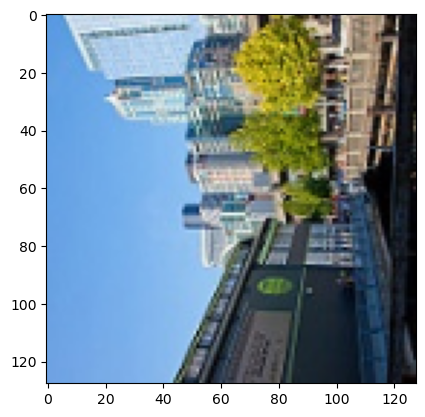

In [95]:
plt.imshow(test.__getitem__(44)[0].permute(2,1,0))

In [116]:
dataset_train = MyDataset(path_train, H=64 , W=64 )
dataset_test = MyDataset(path_test, H=64 , W=64 )

In [117]:
dataloader_train  = DataLoader(dataset_train , batch_size=128 , shuffle=True)
dataloader_test  = DataLoader(dataset_test , batch_size=128 , shuffle=False)

In [118]:
for x , y in dataloader_test:
    break

In [119]:
x.shape  , y.shape

(torch.Size([128, 3, 64, 64]), torch.Size([128]))

In [120]:
from torchvision.transforms import v2

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel , self ).__init__()
        
        self.train_transform = v2.Compose([
            # Randomly flip image horizontally (left ↔ right)
            # Helps model become invariant to left-right orientation
            v2.RandomHorizontalFlip(p=0.5),

            # Randomly flip image vertically (top ↕ bottom)
            # Useful for some datasets, but can be harmful for natural scenes
            v2.RandomVerticalFlip(p=0.2),

            # Randomly rotate image by up to ±20 degrees
            # Improves robustness to object orientation changes
            v2.RandomRotation(degrees=20),

            # Randomly change image brightness, contrast, saturation, and hue
            # Helps model generalize under different lighting conditions
            v2.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            )
        ])
        
        # Block 1: 32 feature maps
        self.b1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 64x64 -> 32x32
            
         
        )

        # Block 2: 64 feature maps
        self.b2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        )

        # Block 3: 128 feature maps
        self.b3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        )

        # Block 4: 256 feature maps
        self.b4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
      
            nn.MaxPool2d(2, 2)  # 8x8 -> 4x4
        )
         # Block 5: 256 feature maps
        self.b5 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2, 2)  # 8x8 -> 4x4
        )

        # Global pooling to reduce spatial dimensions
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # Fully connected classifier
        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 6)  # 6 classes
        )
        
        
    def forward(self, x):
        # Apply augmentation only in training mode
        if self.training:
            x = self.train_transform(x)

        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.global_pool(x)
        x = self.flatten(x)

        return self.fc(x)

In [121]:
model = MyModel()
model.state_dict()

OrderedDict([('b1.0.weight',
              tensor([[[[ 0.1613, -0.0529, -0.1123],
                        [-0.1531,  0.0673,  0.0048],
                        [-0.1743,  0.0775,  0.0745]],
              
                       [[ 0.0813, -0.0028,  0.0798],
                        [ 0.0622,  0.1804,  0.0076],
                        [ 0.1912,  0.1493, -0.1644]],
              
                       [[ 0.1562, -0.1072,  0.1398],
                        [-0.1475,  0.1120,  0.1531],
                        [-0.1044, -0.0974, -0.1181]]],
              
              
                      [[[-0.1761,  0.0262, -0.1065],
                        [-0.1341, -0.1488,  0.1088],
                        [-0.1844, -0.1714,  0.1244]],
              
                       [[ 0.1038,  0.1783, -0.0942],
                        [-0.0449, -0.1257, -0.0390],
                        [ 0.0856,  0.1659,  0.0121]],
              
                       [[-0.0030,  0.1131, -0.1850],
                        [-0

In [122]:
# --- 4. Initialization and Training Utilities ---
def init_weights_cnn(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu') 
        if m.bias is not None:
            nn.init.constant_(m.bias, 0) 
            
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
    elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [123]:
model.apply(init_weights_cnn)
model.state_dict()

OrderedDict([('b1.0.weight',
              tensor([[[[ 8.2441e-02, -1.3808e-01,  1.4031e-01],
                        [-5.3356e-01,  4.9459e-02, -1.4532e-01],
                        [ 1.8802e-01, -1.1882e-01, -3.4267e-02]],
              
                       [[ 3.7768e-01,  4.5120e-01,  1.2683e-01],
                        [ 1.1241e-01, -1.2126e-01, -2.7378e-01],
                        [-4.1480e-02, -6.9192e-01,  7.4603e-02]],
              
                       [[ 5.2442e-01,  1.5494e-01, -1.9942e-01],
                        [-2.1093e-01, -2.7397e-01, -1.3867e-01],
                        [-2.8802e-01, -2.1222e-01,  5.3268e-01]]],
              
              
                      [[[-6.1901e-02,  4.1634e-02,  1.0557e-01],
                        [-3.2347e-01,  1.2277e-01, -3.7911e-01],
                        [-8.1290e-01, -3.9750e-02,  3.5066e-01]],
              
                       [[-2.4229e-01,  1.9774e-01, -1.3802e-01],
                        [-1.7130e-01, -2.1757e

In [124]:
# Calculate accuracy in percentage
def calculate_accuracy(y_true, y_pred):
    correct = (y_true == y_pred).sum().item()
    return (correct / len(y_true)) * 100

In [125]:
# Training loop function
def fit(
    data_loader_train=None,
    data_loader_test=None,
    device=None,
    Model=None,
    epochs: int = 20,
    optimize=None,
    loss_fn=None,
    metrics=None,
    softmax_fun=None,
    scheduler=None  # optional LR scheduler
):

    # Choose device automatically if not provided
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    Model.to(device=device)

    # Track training history
    history_train_loss = []
    history_test_loss = []
    history_train_acc = []
    history_test_acc = []

    for epoch in range(epochs):

        # ==================== TRAINING PHASE ====================
        Model.train()
        running_train_loss = 0.0
        running_train_acc = 0.0

        for x_train, y_train in data_loader_train:
            x_train, y_train = x_train.to(device), y_train.to(device)

            optimize.zero_grad()
            y_pred = Model(x_train)
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            optimize.step()

            running_train_loss += loss.item() * x_train.size(0)

            # Convert logits to probabilities then predictions
            probabilities_train = softmax_fun(y_pred, dim=1)
            predictions_train = torch.argmax(probabilities_train, dim=1)

            running_train_acc += metrics(y_train, predictions_train) * x_train.size(0)

        epoch_train_loss = running_train_loss / len(data_loader_train.dataset)
        epoch_train_acc = running_train_acc / len(data_loader_train.dataset)

        history_train_loss.append(epoch_train_loss)
        history_train_acc.append(epoch_train_acc)

        # ==================== VALIDATION PHASE ====================
        Model.eval()

        running_test_loss = 0.0
        running_test_acc = 0.0

        with torch.inference_mode():
            for x_test, y_test in data_loader_test:
                x_test, y_test = x_test.to(device), y_test.to(device)

                y_pred_test = Model(x_test)
                loss_test = loss_fn(y_pred_test, y_test)

                running_test_loss += loss_test.item() * x_test.size(0)

                probabilities_test = softmax_fun(y_pred_test, dim=1)
                predictions_test = torch.argmax(probabilities_test, dim=1)

                running_test_acc += metrics(y_test, predictions_test) * x_test.size(0)

        epoch_test_loss = running_test_loss / len(data_loader_test.dataset)
        epoch_test_acc = running_test_acc / len(data_loader_test.dataset)

        history_test_loss.append(epoch_test_loss)
        history_test_acc.append(epoch_test_acc)

        # ==================== SCHEDULER STEP ====================
        # Update learning rate based on validation loss (if scheduler exists)
        if scheduler is not None:
            current_lr = optimize.param_groups[0]['lr']
            scheduler.step(epoch_test_loss)

        # ==================== LOGGING ====================
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] ----------------------------------------")
            print(f"  [Train] Loss: {epoch_train_loss:.4f} | Accuracy: {epoch_train_acc:.2f}%")
            print(f"  [Test]  Loss: {epoch_test_loss:.4f} | Accuracy: {epoch_test_acc:.2f}% | LR: {current_lr:.6f}")

    return history_train_loss, history_test_loss, history_train_acc, history_test_acc

In [126]:
# Optimizer (Adam is a good default for CNNs)
optimzer = torch.optim.Adam(model.parameters(), lr=0.001)

# Loss function for multi-class classification
loss_fun = nn.CrossEntropyLoss()

# LR scheduler: reduces learning rate when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimzer,
    mode='min',      # we want loss to go down
    factor=0.1,      # reduce LR by 10x
    patience=3,      # wait 3 epochs before reducing
    verbose=True     # print when LR changes
)

# Use GPU if available, otherwise fallback to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [127]:
# Start training process
history_train_loss, history_test_loss, history_train_acc, history_test_acc = fit(
    data_loader_train=dataloader_train,
    data_loader_test=dataloader_test,
    device=device,
    Model=model,  # make sure model name matches MyDeepCNN instance
    epochs=20,
    optimize=optimzer,
    loss_fn=loss_fun,
    metrics=calculate_accuracy,
    softmax_fun=torch.softmax,
    scheduler=scheduler  # LR scheduler is enabled here
)

Epoch [01/20] ----------------------------------------
  [Train] Loss: 1.0900 | Accuracy: 58.51%
  [Test]  Loss: 0.7914 | Accuracy: 72.70% | LR: 0.001000
Epoch [02/20] ----------------------------------------
  [Train] Loss: 0.8133 | Accuracy: 69.84%
  [Test]  Loss: 0.6530 | Accuracy: 75.63% | LR: 0.001000
Epoch [04/20] ----------------------------------------
  [Train] Loss: 0.6250 | Accuracy: 77.48%
  [Test]  Loss: 0.6603 | Accuracy: 74.33% | LR: 0.001000
Epoch [06/20] ----------------------------------------
  [Train] Loss: 0.5495 | Accuracy: 80.25%
  [Test]  Loss: 0.7110 | Accuracy: 76.87% | LR: 0.001000
Epoch [08/20] ----------------------------------------
  [Train] Loss: 0.4904 | Accuracy: 82.78%
  [Test]  Loss: 0.6789 | Accuracy: 76.33% | LR: 0.001000
Epoch [10/20] ----------------------------------------
  [Train] Loss: 0.4534 | Accuracy: 83.73%
  [Test]  Loss: 0.4196 | Accuracy: 85.27% | LR: 0.001000
Epoch [12/20] ----------------------------------------
  [Train] Loss: 0.425

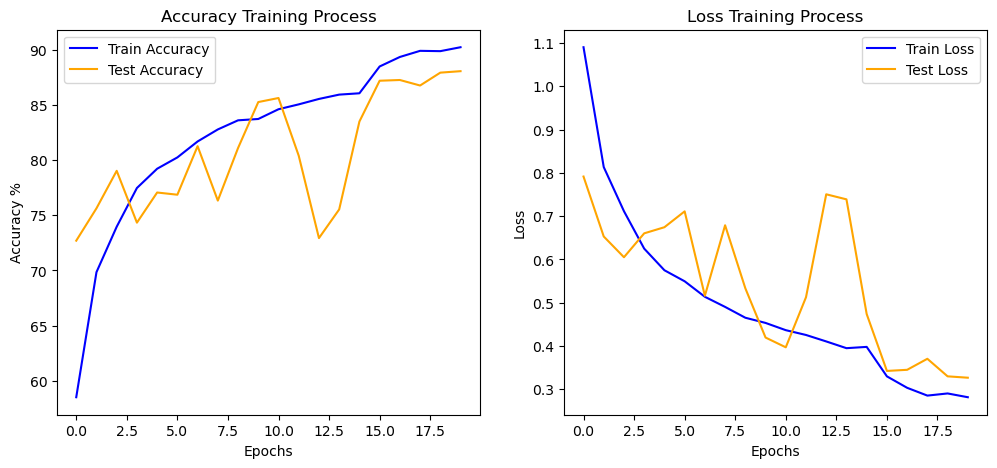

In [128]:
# Plot training results (accuracy + loss)
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_train_acc, label='Train Accuracy', color='blue')
plt.plot(history_test_acc, label='Test Accuracy', color='orange')
plt.title('Accuracy Training Process')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_train_loss, label='Train Loss', color='blue')
plt.plot(history_test_loss, label='Test Loss', color='orange')
plt.title('Loss Training Process')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [130]:
torch.save(model.state_dict() , "model.pt")

In [140]:
! streamlit run app.py

^C
